In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')                          # auth popup, once per session
RESULTS_DIR = '/content/drive/MyDrive/thesis_results'  # change name if you like
os.makedirs(RESULTS_DIR, exist_ok=True)
os.chdir(RESULTS_DIR)                                   # all relative saves now land here
print('Saving to:', os.getcwd())

Mounted at /content/drive
Saving to: /content/drive/MyDrive/thesis_results


In [2]:
# Imports

## Core libraries
import numpy as np
import matplotlib.pyplot as plt

## TensorFlow / Keras
import tensorflow as tf
import keras
from keras import ops, layers
from keras.callbacks import Callback
from keras.models import Sequential, Model
from keras.layers import Input, Conv2D, Dense


In [3]:
# Setting seeds

np.random.seed(1999)
tf.random.set_seed(1999)


In [4]:
# Loading the dataset

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

## Feature scaling (mapping pixel values to [0,1])
'''
This is used as neural network training via gradient descent is sensitive to the
scale of inputs (through activations a = Wx + b). This causes gradients to vanish
and makes the loss landscape poorly conditioned.
'''
x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

''' Recalling our y values are our categories '''
y_train_full = keras.utils.to_categorical(y_train_full, 10)
y_test = keras.utils.to_categorical(y_test, 10)

## Setting up our validation dataset
n_val = int(0.2 * len(x_train_full))
perm = np.random.permutation(len(x_train_full))
val_idx, train_idx = perm[:n_val], perm[n_val:]
x_val, y_val = x_train_full[val_idx], y_train_full[val_idx]
x_train, y_train = x_train_full[train_idx], y_train_full[train_idx]

## Check
print(f"train: {x_train.shape} val: {x_val.shape} test: {x_test.shape}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
train: (40000, 32, 32, 3) val: (10000, 32, 32, 3) test: (10000, 32, 32, 3)


In [5]:
# Augmenting the dataset
'''
This involves creating new training examples by applying label preserving
transformations to existing examples e.g. flips, crops, scaling, colour jitter,
adding noise, ...
'''

'''
Applying three transformations in sequence, we pad the image with black 0s,
then randomly crop the newly padded image (so the model learns that a shifted
horse picture is still a horse), and then randomly mirroring the image from left
to right.
'''
augment = keras.Sequential([layers.ZeroPadding2D(padding=4),
                            layers.RandomCrop(32, 32),
                            layers.RandomFlip("horizontal")])

batch_size = 128

'''
This builds the full training data pipeline, where:
- The from_tensor_slices((x_train, y_train)) wraps the numpy arrays into a
  tf.data.Dataset that has image label pairs one at a time.
- For .shuffle(len(x_train)) - this shifts the entire dataset after each epoch.
- For .map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
  this applies the augmentation pipeline to each batch of images whilst leaving
  labels untouched. The training=True is important because RandomCrop and
  RandomFlip only apply their transformations during training. The
  num_parallel_calls=tf.data.AUTOTUNE lets TensorFlow decide how many batches to
  augment in parallel across CPU threads.
'''
train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(len(x_train)).batch(batch_size).map(lambda x, y: (augment(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE))

### Recalling that there is no augmentation for validation and test datasets
val_ds  = (tf.data.Dataset.from_tensor_slices((x_val,  y_val ))
           .batch(batch_size).prefetch(tf.data.AUTOTUNE))
test_ds = (tf.data.Dataset.from_tensor_slices((x_test, y_test))
           .batch(batch_size).prefetch(tf.data.AUTOTUNE))


In [6]:
# MC Dropout layer + Residual block with dropout between convolutions
'''
The MCDropout class subclasses keras.layers.Dropout and overrides its call
method so that training=True is always forced. This means the stochastic
masking remains active at test time, which is exactly what Gal & Ghahramani
(2016) showed is equivalent to drawing samples from an approximate posterior
over the weights of a deep network.
'''
class MCDropout(layers.Dropout):
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

'''
The residual block here matches the plain ResNet-20 block but inserts an
MCDropout layer between the two convolutions inside each block. We follow the
Summative-2 spec (and the original Gal & Ghahramani placement of dropout
inside the residual unit) so that the BNN approximation lives in the
representation-extraction part of the network rather than at the classifier
head.
'''
class ResidualBlock(keras.layers.Layer):

    def __init__(self, filters, stride=1, dropout_rate=0.0, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.stride = stride
        self.dropout_rate = dropout_rate

        self.conv1 = layers.Conv2D(filters, 3, strides=stride, padding="same",
                                   kernel_regularizer=keras.regularizers.L2(1e-4),
                                   kernel_initializer="he_normal")
        self.bn1 = layers.BatchNormalization()

        ### Dropout layer is constructed only if rate > 0 (so the same class can also build a deterministic block).
        self.drop = MCDropout(dropout_rate) if dropout_rate > 0 else None

        self.conv2 = layers.Conv2D(filters, 3, padding="same",
                                   kernel_regularizer=keras.regularizers.L2(1e-4),
                                   kernel_initializer="he_normal")
        self.bn2 = layers.BatchNormalization()
        self.relu = layers.Activation("relu")

    def build(self, input_shape):
        in_channels = input_shape[-1]

        if self.stride != 1 or in_channels != self.filters:
            self.proj = layers.Conv2D(self.filters, 1, strides=self.stride, padding="valid",
                                      kernel_regularizer=keras.regularizers.L2(1e-4),
                                      kernel_initializer="he_normal")
            self.bn_proj = layers.BatchNormalization()
        else:
            self.proj = None

        super().build(input_shape)

    def call(self, x):
        if self.proj is not None:
            shortcut = self.bn_proj(self.proj(x))
        else:
            shortcut = x

        ### Main path: conv -> BN -> ReLU -> (MC Dropout if active) -> conv -> BN
        out = self.relu(self.bn1(self.conv1(x)))
        if self.drop is not None:
            out = self.drop(out)
        out = self.bn2(self.conv2(out))

        return self.relu(out + shortcut)

    def get_config(self):
        config = super().get_config()
        config.update({"filters": self.filters,
                       "stride": self.stride,
                       "dropout_rate": self.dropout_rate})
        return config


In [7]:
# build_resnet20 — MC Dropout variant
'''
Identical architecture to the deterministic build_resnet20, except a
dropout_rate argument is propagated to every residual block. Each block then
inserts an MCDropout layer between its two convolutions; the layer is always
stochastic (training=True forced) so that test-time forward passes draw
samples from the approximate posterior.
'''
def build_resnet20(dropout_rate=0.0):
    inputs = keras.Input(shape=(32, 32, 3))

    x = layers.Conv2D(16, 3, padding="same",
                      kernel_regularizer=keras.regularizers.L2(1e-4),
                      kernel_initializer="he_normal")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    for _ in range(3):
        x = ResidualBlock(16, dropout_rate=dropout_rate)(x)

    x = ResidualBlock(32, stride=2, dropout_rate=dropout_rate)(x)
    for _ in range(2):
        x = ResidualBlock(32, dropout_rate=dropout_rate)(x)

    x = ResidualBlock(64, stride=2, dropout_rate=dropout_rate)(x)
    for _ in range(2):
        x = ResidualBlock(64, dropout_rate=dropout_rate)(x)

    x = layers.GlobalAveragePooling2D()(x)

    outputs = layers.Dense(10, kernel_initializer="he_normal")(x)

    return keras.Model(inputs, outputs)


In [8]:
# Building MC Dropout model
'''
We choose dropout_rate=0.1 following the Summative-2 hyperparameter sweep
({0.1, 0.3, 0.5}) which found 0.1 gave the best validation accuracy. Higher
rates over-regularised ResNet-20 for CIFAR-10.

Note: the MC Dropout model uses the same training-time loss and optimiser as
the deterministic baseline; the only architectural change is the dropout
layer inside every residual block (which stays active at test time).
'''
DROPOUT_RATE = 0.1

mc_model = build_resnet20(dropout_rate=DROPOUT_RATE)
mc_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block (ResidualBlock)  │ (None, 32, 32, 16)     │         4,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_1                │ (None, 32, 32, 16)     │         4,768 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_2                │ (None, 32, 32, 16)     │         4,768 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_3                │ (None, 16, 16, 32)     │        14,816 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_4                │ (None, 16, 16, 32)     │        18,752 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_5                │ (None, 16, 16, 32)     │        18,752 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_6                │ (None, 8, 8, 64)       │        58,304 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_7                │ (None, 8, 8, 64)       │        74,368 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_8                │ (None, 8, 8, 64)       │        74,368 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 274,826 (1.05 MB)

 Trainable params: 273,258 (1.04 MB)

 Non-trainable params: 1,568 (6.12 KB)

In [9]:
# Training MC Dropout model

def lr_schedule(epoch, lr):
    if epoch in (100, 150):
        return lr * 0.1
    return lr


In [10]:
# Compiling

mc_model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.1, momentum=0.9),
                 loss=keras.losses.CategoricalCrossentropy(from_logits=True),
                 metrics=["categorical_accuracy"])


In [11]:
# Callbacks for checkpoints

mc_callbacks = [keras.callbacks.ModelCheckpoint("resnet20_mc_best.weights.h5",
                                                monitor="val_loss",
                                                save_best_only=True,
                                                save_weights_only=True),
                keras.callbacks.LearningRateScheduler(lr_schedule, verbose=1)]


In [12]:
# Training

history_mc = mc_model.fit(train_ds,
                          epochs=200,
                          validation_data=val_ds,
                          callbacks=mc_callbacks)

mc_model.load_weights("resnet20_mc_best.weights.h5")

# Single-sample test evaluation (deterministic-style readout for sanity)
mc_loss, mc_acc = mc_model.evaluate(test_ds, verbose=0)
print(f"\nMC Dropout single-sample test loss: {mc_loss:.4f}  Test accuracy: {mc_acc:.4f}")



Epoch 1: LearningRateScheduler setting learning rate to 0.10000000149011612.
Epoch 1/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 87ms/step - categorical_accuracy: 0.3450 - loss: 1.9202 - val_categorical_accuracy: 0.3522 - val_loss: 1.9589 - learning_rate: 0.1000

Epoch 2: LearningRateScheduler setting learning rate to 0.10000000149011612.
Epoch 2/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - categorical_accuracy: 0.5243 - loss: 1.4621 - val_categorical_accuracy: 0.4181 - val_loss: 2.2009 - learning_rate: 0.1000

Epoch 3: LearningRateScheduler setting learning rate to 0.10000000149011612.
Epoch 3/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - categorical_accuracy: 0.6103 - loss: 1.2366 - val_categorical_accuracy: 0.5626 - val_loss: 1.4783 - learning_rate: 0.1000

Epoch 4: LearningRateScheduler setting learning rate to 0.10000000149011612.
Epoch 4/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - categorical_accuracy: 0.6629 - loss: 1.1027 - val_categorical_accuracy: 0.4571 - val_loss: 1.9400

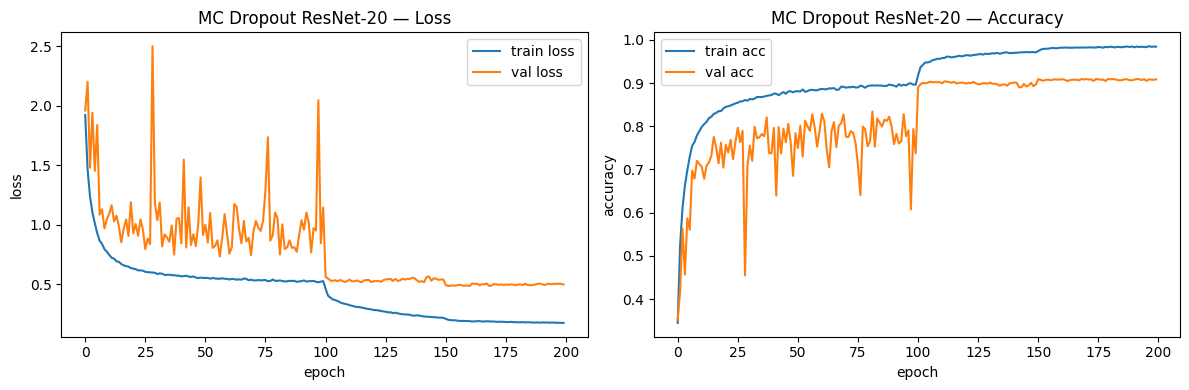

In [13]:
# Plotting training curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

## Plot 1
ax1.plot(history_mc.history["loss"], label="train loss")
ax1.plot(history_mc.history["val_loss"], label="val loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss")
ax1.set_title("MC Dropout ResNet-20 — Loss"); ax1.legend()

## Plot 2
ax2.plot(history_mc.history["categorical_accuracy"], label="train acc")
ax2.plot(history_mc.history["val_categorical_accuracy"], label="val acc")
ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy")
ax2.set_title("MC Dropout ResNet-20 — Accuracy"); ax2.legend()
plt.tight_layout(); plt.show()


In [14]:
# Loading SVHN as the out-of-distribution reference set
'''
Per the proposal §3.5, SVHN (street view of house numbers) is used as the
OOD test set. SVHN images are 32x32 colour photos like CIFAR-10, but of
digits, so a CIFAR-10 trained model should ideally report higher predictive
entropy on SVHN inputs than on its in-distribution CIFAR-10 test images.

We download the official SVHN test split (.mat) directly instead of using
tensorflow_datasets, which removes a flaky lazy-import dependency. The ~26k
images rescale to [0, 1] to match CIFAR-10 preprocessing; cached after the
first download.
'''
import os, urllib.request
from scipy.io import loadmat

svhn_path = "svhn_test_32x32.mat"
if not os.path.exists(svhn_path):
    urllib.request.urlretrieve(
        "http://ufldl.stanford.edu/housenumbers/test_32x32.mat", svhn_path)

mat = loadmat(svhn_path)
# mat["X"] has shape (32, 32, 3, N); move the sample axis to the front, rescale.
x_svhn = np.transpose(mat["X"], (3, 0, 1, 2)).astype("float32") / 255.0

print(f"SVHN OOD set: {x_svhn.shape}")


SVHN OOD set: (26032, 32, 32, 3)


In [15]:
# Loading CIFAR-10-C (common corruptions) as the in-distribution shift set
'''
Per the proposal §3.5, CIFAR-10-C (Hendrycks & Dietterich 2019) is the
corruption / covariate-shift evaluation set: the same 10 CIFAR-10 classes but
with algorithmic corruptions at graded severity. Unlike SVHN (far / semantic
OOD), these are in-domain-but-degraded inputs, so they probe a different kind
of uncertainty.

Patched folder handling:
- verifies labels.npy and every expected corruption .npy file;
- repairs partial extractions by re-extracting CIFAR-10-C.tar;
- re-downloads the tar if it is missing, invalid, or incomplete;
- raises a clear error listing missing files if the folder is still incomplete.
'''
import os, urllib.request, tarfile
import numpy as np

SEVERITY = globals().get("SEVERITY", 3)
CORRUPTIONS = globals().get("CORRUPTIONS", [
    "gaussian_noise", "shot_noise", "impulse_noise", "defocus_blur",
    "glass_blur", "motion_blur", "zoom_blur", "snow", "frost", "fog",
    "brightness", "contrast", "elastic_transform", "pixelate", "jpeg_compression",
])

CIFAR10C_ROOT = "CIFAR-10-C"
CIFAR10C_TAR = "CIFAR-10-C.tar"
CIFAR10C_URLS = [
    "https://zenodo.org/records/2535967/files/CIFAR-10-C.tar?download=1",
    "https://zenodo.org/record/2535967/files/CIFAR-10-C.tar",
]


def _required_cifar10c_files(corruptions=CORRUPTIONS):
    return ["labels.npy"] + [f"{corr}.npy" for corr in corruptions]


def _cifar10c_score(root, corruptions=CORRUPTIONS):
    try:
        file_set = set(os.listdir(root))
    except OSError:
        return 0
    required = set(_required_cifar10c_files(corruptions))
    return len(required.intersection(file_set))


def _find_cifar10c_root(start=".", corruptions=CORRUPTIONS):
    """Return the directory that best looks like the extracted CIFAR-10-C root."""
    required = set(_required_cifar10c_files(corruptions))
    candidates = []

    # Fast-path the expected folder first.
    if os.path.isdir(CIFAR10C_ROOT):
        candidates.append((_cifar10c_score(CIFAR10C_ROOT, corruptions), CIFAR10C_ROOT))

    # Then support nested layouts produced by some archive/extraction tools.
    for root, dirs, files in os.walk(start):
        # Avoid descending into hidden/checkpoint folders, which can make Drive scans noisy.
        dirs[:] = [d for d in dirs if not d.startswith(".") and d != "__MACOSX"]
        file_set = set(files)
        if "labels.npy" in file_set or any(f"{corr}.npy" in file_set for corr in corruptions):
            candidates.append((len(required.intersection(file_set)), root))

    if not candidates:
        return CIFAR10C_ROOT

    candidates.sort(key=lambda item: item[0], reverse=True)
    return candidates[0][1]


def _missing_cifar10c_files(root, corruptions=CORRUPTIONS):
    return [
        filename
        for filename in _required_cifar10c_files(corruptions)
        if not os.path.exists(os.path.join(root, filename))
    ]


def _safe_extract_tar(tar, path="."):
    """Protect against path traversal before extracting the downloaded tar."""
    base = os.path.abspath(path)
    for member in tar.getmembers():
        member_path = os.path.abspath(os.path.join(path, member.name))
        if not (member_path == base or member_path.startswith(base + os.sep)):
            raise RuntimeError(f"Unsafe path in tar archive: {member.name}")
    tar.extractall(path)


def _download_cifar10c_tar(tar_path=CIFAR10C_TAR, urls=CIFAR10C_URLS):
    last_error = None
    for url in urls:
        try:
            print(f"Downloading CIFAR-10-C from {url}")
            urllib.request.urlretrieve(url, tar_path)
            return
        except Exception as exc:
            last_error = exc
            print(f"Download failed from {url}: {exc}")

    raise RuntimeError("Could not download CIFAR-10-C from any configured URL.") from last_error


def _extract_cifar10c_tar(tar_path=CIFAR10C_TAR):
    try:
        with tarfile.open(tar_path) as tar:
            _safe_extract_tar(tar, ".")
    except (tarfile.TarError, EOFError) as exc:
        print("Existing CIFAR-10-C tar is invalid or incomplete; re-downloading.")
        if os.path.exists(tar_path):
            os.remove(tar_path)
        _download_cifar10c_tar(tar_path)
        with tarfile.open(tar_path) as tar:
            _safe_extract_tar(tar, ".")


def load_cifar10c(severity=SEVERITY, corruptions=CORRUPTIONS, root=CIFAR10C_ROOT):
    """Download/extract CIFAR-10-C if needed, verify all files, then load one severity."""
    if not (1 <= int(severity) <= 5):
        raise ValueError("CIFAR-10-C severity must be an integer from 1 to 5.")
    severity = int(severity)

    root = _find_cifar10c_root(root, corruptions)
    missing = _missing_cifar10c_files(root, corruptions)

    if missing:
        print(f"CIFAR-10-C is incomplete at '{root}'. Missing {len(missing)} file(s): {missing[:5]}")
        if not os.path.exists(CIFAR10C_TAR):
            print("CIFAR-10-C tar is not present; downloading it now (~2.9 GB).")
            _download_cifar10c_tar(CIFAR10C_TAR)
        else:
            print("CIFAR-10-C tar already exists; re-extracting it to repair the dataset.")

        _extract_cifar10c_tar(CIFAR10C_TAR)
        root = _find_cifar10c_root(root, corruptions)
        missing = _missing_cifar10c_files(root, corruptions)

    if missing:
        raise FileNotFoundError(
            "CIFAR-10-C is still incomplete after extraction. "
            f"Root checked: '{root}'. Missing files include: {missing[:10]}. "
            "Delete CIFAR-10-C and CIFAR-10-C.tar, then rerun this cell."
        )

    lo, hi = (severity - 1) * 10000, severity * 10000
    labels_full = np.load(os.path.join(root, "labels.npy"))
    labels_block = labels_full[lo:hi] if labels_full.shape[0] > 10000 else labels_full

    x_parts, y_parts = [], []
    for corr in corruptions:
        path = os.path.join(root, f"{corr}.npy")
        arr = np.load(path)[lo:hi]    # (10000, 32, 32, 3) uint8
        x_parts.append(arr)
        y_parts.append(labels_block)

    x_cifar10c = np.concatenate(x_parts, axis=0).astype("float32") / 255.0
    labels_cifar10c = np.concatenate(y_parts, axis=0).astype("int64")

    print(
        f"CIFAR-10-C set (severity {severity}, {len(corruptions)} corruptions): "
        f"{x_cifar10c.shape}, labels {labels_cifar10c.shape}"
    )
    print(f"CIFAR-10-C root: {root}")

    return x_cifar10c, labels_cifar10c


# Execute the load in this cell so Run all prepares CIFAR-10-C before prediction.
x_cifar10c, labels_cifar10c = load_cifar10c(SEVERITY, CORRUPTIONS)


CIFAR-10-C set (severity 3, 15 corruptions): (150000, 32, 32, 3), labels (150000,)
CIFAR-10-C root: CIFAR-10-C


In [16]:
# MC Dropout predictive distribution (S samples)
'''
For each input we run S=30 stochastic forward passes (each with an
independent dropout mask). Averaging the resulting softmax probabilities
gives the MC estimate of the posterior predictive distribution. Storing all
S sets of probabilities separately is what lets the evaluation file compute
the decomposition:
    Total uncertainty  = H[ mean_s p_s ]
    Aleatoric          = mean_s H[ p_s ]
    Epistemic (MI)     = Total - Aleatoric
which is the standard mutual-information style split (Depeweg et al. 2018).
'''


# Guard: load CIFAR-10-C here if the dedicated loading cell was skipped.
# This prevents this notebook from producing results without CIFAR-10-C outputs.
if "x_cifar10c" not in globals() or "labels_cifar10c" not in globals():
    print("CIFAR-10-C was not loaded before prediction; loading it now.")
    if "load_cifar10c" not in globals():
        import os, urllib.request, tarfile
        import numpy as np

        SEVERITY = globals().get("SEVERITY", 3)
        CORRUPTIONS = globals().get("CORRUPTIONS", [
            "gaussian_noise", "shot_noise", "impulse_noise", "defocus_blur",
            "glass_blur", "motion_blur", "zoom_blur", "snow", "frost", "fog",
            "brightness", "contrast", "elastic_transform", "pixelate", "jpeg_compression",
        ])

        CIFAR10C_ROOT = "CIFAR-10-C"
        CIFAR10C_TAR = "CIFAR-10-C.tar"
        CIFAR10C_URLS = [
            "https://zenodo.org/records/2535967/files/CIFAR-10-C.tar?download=1",
            "https://zenodo.org/record/2535967/files/CIFAR-10-C.tar",
        ]


        def _required_cifar10c_files(corruptions=CORRUPTIONS):
            return ["labels.npy"] + [f"{corr}.npy" for corr in corruptions]


        def _cifar10c_score(root, corruptions=CORRUPTIONS):
            try:
                file_set = set(os.listdir(root))
            except OSError:
                return 0
            required = set(_required_cifar10c_files(corruptions))
            return len(required.intersection(file_set))


        def _find_cifar10c_root(start=".", corruptions=CORRUPTIONS):
            """Return the directory that best looks like the extracted CIFAR-10-C root."""
            required = set(_required_cifar10c_files(corruptions))
            candidates = []

            # Fast-path the expected folder first.
            if os.path.isdir(CIFAR10C_ROOT):
                candidates.append((_cifar10c_score(CIFAR10C_ROOT, corruptions), CIFAR10C_ROOT))

            # Then support nested layouts produced by some archive/extraction tools.
            for root, dirs, files in os.walk(start):
                # Avoid descending into hidden/checkpoint folders, which can make Drive scans noisy.
                dirs[:] = [d for d in dirs if not d.startswith(".") and d != "__MACOSX"]
                file_set = set(files)
                if "labels.npy" in file_set or any(f"{corr}.npy" in file_set for corr in corruptions):
                    candidates.append((len(required.intersection(file_set)), root))

            if not candidates:
                return CIFAR10C_ROOT

            candidates.sort(key=lambda item: item[0], reverse=True)
            return candidates[0][1]


        def _missing_cifar10c_files(root, corruptions=CORRUPTIONS):
            return [
                filename
                for filename in _required_cifar10c_files(corruptions)
                if not os.path.exists(os.path.join(root, filename))
            ]


        def _safe_extract_tar(tar, path="."):
            """Protect against path traversal before extracting the downloaded tar."""
            base = os.path.abspath(path)
            for member in tar.getmembers():
                member_path = os.path.abspath(os.path.join(path, member.name))
                if not (member_path == base or member_path.startswith(base + os.sep)):
                    raise RuntimeError(f"Unsafe path in tar archive: {member.name}")
            tar.extractall(path)


        def _download_cifar10c_tar(tar_path=CIFAR10C_TAR, urls=CIFAR10C_URLS):
            last_error = None
            for url in urls:
                try:
                    print(f"Downloading CIFAR-10-C from {url}")
                    urllib.request.urlretrieve(url, tar_path)
                    return
                except Exception as exc:
                    last_error = exc
                    print(f"Download failed from {url}: {exc}")

            raise RuntimeError("Could not download CIFAR-10-C from any configured URL.") from last_error


        def _extract_cifar10c_tar(tar_path=CIFAR10C_TAR):
            try:
                with tarfile.open(tar_path) as tar:
                    _safe_extract_tar(tar, ".")
            except (tarfile.TarError, EOFError) as exc:
                print("Existing CIFAR-10-C tar is invalid or incomplete; re-downloading.")
                if os.path.exists(tar_path):
                    os.remove(tar_path)
                _download_cifar10c_tar(tar_path)
                with tarfile.open(tar_path) as tar:
                    _safe_extract_tar(tar, ".")


        def load_cifar10c(severity=SEVERITY, corruptions=CORRUPTIONS, root=CIFAR10C_ROOT):
            """Download/extract CIFAR-10-C if needed, verify all files, then load one severity."""
            if not (1 <= int(severity) <= 5):
                raise ValueError("CIFAR-10-C severity must be an integer from 1 to 5.")
            severity = int(severity)

            root = _find_cifar10c_root(root, corruptions)
            missing = _missing_cifar10c_files(root, corruptions)

            if missing:
                print(f"CIFAR-10-C is incomplete at '{root}'. Missing {len(missing)} file(s): {missing[:5]}")
                if not os.path.exists(CIFAR10C_TAR):
                    print("CIFAR-10-C tar is not present; downloading it now (~2.9 GB).")
                    _download_cifar10c_tar(CIFAR10C_TAR)
                else:
                    print("CIFAR-10-C tar already exists; re-extracting it to repair the dataset.")

                _extract_cifar10c_tar(CIFAR10C_TAR)
                root = _find_cifar10c_root(root, corruptions)
                missing = _missing_cifar10c_files(root, corruptions)

            if missing:
                raise FileNotFoundError(
                    "CIFAR-10-C is still incomplete after extraction. "
                    f"Root checked: '{root}'. Missing files include: {missing[:10]}. "
                    "Delete CIFAR-10-C and CIFAR-10-C.tar, then rerun this cell."
                )

            lo, hi = (severity - 1) * 10000, severity * 10000
            labels_full = np.load(os.path.join(root, "labels.npy"))
            labels_block = labels_full[lo:hi] if labels_full.shape[0] > 10000 else labels_full

            x_parts, y_parts = [], []
            for corr in corruptions:
                path = os.path.join(root, f"{corr}.npy")
                arr = np.load(path)[lo:hi]    # (10000, 32, 32, 3) uint8
                x_parts.append(arr)
                y_parts.append(labels_block)

            x_cifar10c = np.concatenate(x_parts, axis=0).astype("float32") / 255.0
            labels_cifar10c = np.concatenate(y_parts, axis=0).astype("int64")

            print(
                f"CIFAR-10-C set (severity {severity}, {len(corruptions)} corruptions): "
                f"{x_cifar10c.shape}, labels {labels_cifar10c.shape}"
            )
            print(f"CIFAR-10-C root: {root}")

            return x_cifar10c, labels_cifar10c
    x_cifar10c, labels_cifar10c = load_cifar10c(SEVERITY, CORRUPTIONS)

S = 30

def mc_predictive(x_ds_or_array, S=S, batch_size=128):
    '''
    Returns:
      all_probs: (S, N, 10) per-sample softmax probabilities
      mean_probs: (N, 10) Monte Carlo mean
    Accepts either a tf.data.Dataset or a numpy array.
    '''
    if isinstance(x_ds_or_array, np.ndarray):
        ds = tf.data.Dataset.from_tensor_slices(x_ds_or_array).batch(batch_size)
        get_x = lambda b: b
    else:
        ds = x_ds_or_array
        get_x = lambda b: b[0]

    samples = []
    for _ in range(S):
        per_sample = []
        for batch in ds:
            x_batch = get_x(batch)
            ### training=True keeps the dropout masks stochastic; the MCDropout subclass already forces this, but we pass it explicitly for clarity.
            logits = mc_model(x_batch, training=True)
            per_sample.append(tf.nn.softmax(logits, axis=-1).numpy())
        samples.append(np.concatenate(per_sample, axis=0))
    all_probs = np.stack(samples, axis=0)              # (S, N, 10)
    mean_probs = all_probs.mean(axis=0)                 # (N, 10)
    return all_probs, mean_probs

print("Running MC inference on CIFAR-10 test set...")
all_probs_test, probs_test = mc_predictive(test_ds, S=S)
preds_test  = np.argmax(probs_test, axis=1)
labels_test = np.argmax(y_test, axis=1)
print(f"MC Dropout (S={S}) test accuracy: {(preds_test == labels_test).mean():.4f}")

print("Running MC inference on SVHN OOD set...")
all_probs_svhn, probs_svhn = mc_predictive(x_svhn, S=S)

print("Running MC inference on CIFAR-10-C (severity 3)...")
all_probs_cifar10c, probs_cifar10c = mc_predictive(x_cifar10c, S=S)

print(f"all_probs_test:     {all_probs_test.shape}")
print(f"all_probs_svhn:     {all_probs_svhn.shape}")
print(f"all_probs_cifar10c: {all_probs_cifar10c.shape}")


Running MC inference on CIFAR-10 test set...
MC Dropout (S=30) test accuracy: 0.9085
Running MC inference on SVHN OOD set...
Running MC inference on CIFAR-10-C (severity 3)...
all_probs_test:     (30, 10000, 10)
all_probs_svhn:     (30, 26032, 10)
all_probs_cifar10c: (30, 150000, 10)


In [17]:
# Saving raw outputs for the evaluation file
'''
Same .npz schema as the deterministic file. The S=30 per-sample arrays let
the eval file recover the mutual-information uncertainty decomposition.
'''
np.savez("mc_dropout_results.npz",
         model_name="mc_dropout",
         probs_test=probs_test,
         labels_test=labels_test,
         preds_test=preds_test,
         probs_svhn=probs_svhn,
         probs_cifar10c=probs_cifar10c,
         labels_cifar10c=labels_cifar10c,
         cifar10c_severity=SEVERITY,
         all_probs_test=all_probs_test,
         all_probs_svhn=all_probs_svhn,
         all_probs_cifar10c=all_probs_cifar10c)

print("Saved mc_dropout_results.npz")


Saved mc_dropout_results.npz
